In [22]:
import numpy as np
import matplotlib.pyplot as plt

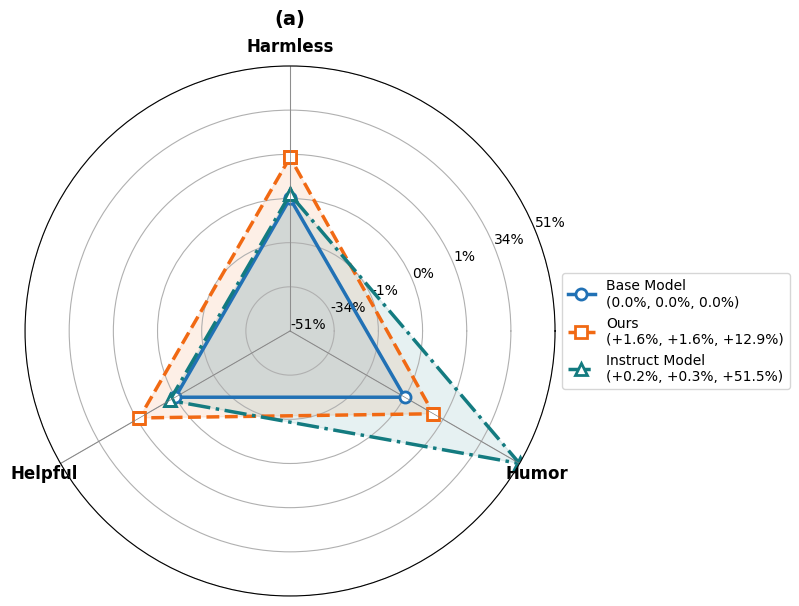

In [57]:
def create_radar_plot(categories, values_dict, title=""):
    """
    Create a radar plot showing relative improvements over the base model with balanced scaling.
    """
    num_vars = len(categories)
    angles = np.linspace(np.pi/2, 2.5*np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
    
    # Calculate relative improvements with custom scaling
    base_values = values_dict['Base Model']
    relative_values_dict = {}
    
    # Custom scaling factors for different metrics
    scale_factors = {
        'Harmless': 5,    # Amplify small differences
        'Helpful': 5,     # Amplify small differences
        'Humor': 0.5      # Reduce large differences
    }
    
    for model, values in values_dict.items():
        # Calculate scaled relative improvements
        relative_values = []
        for val, base_val, cat in zip(values, base_values, categories):
            pct_change = (val - base_val) / base_val * 100
            scaled_change = pct_change * scale_factors[cat]
            relative_values.append(scaled_change)
        relative_values_dict[model] = relative_values
    
    # Plotting style
    colors = ['#2171b5', '#f16913', '#137B80']
    markers = ['o', 's', '^']
    line_styles = ['-', '--', '-.']
    
    # Plot data
    for idx, (label, values) in enumerate(relative_values_dict.items()):
        values = values + [values[0]]
        
        # Create label showing original (unscaled) improvements
        original_improvements = [(val - base_val) / base_val * 100 
                               for val, base_val in zip(values_dict[label], base_values)]
        improvements = [f"{'+' if v > 0 else ''}{v:.1f}%" 
                       for v in original_improvements]
        label_text = f"{label}\n({', '.join(improvements)})"
        
        ax.plot(angles, values, 
                marker=markers[idx],
                linestyle=line_styles[idx],
                linewidth=2.5,
                label=label_text,
                color=colors[idx],
                markersize=8,
                markerfacecolor='white',
                markeredgewidth=2)
        
        ax.fill(angles, values, color=colors[idx], alpha=0.1)
    
    # Enhance category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f"{cat}" for cat in categories], 
                       size=12, fontweight='bold')
    
    # Customize grid
    ax.grid(True)
    max_val = max(max(vals) for vals in relative_values_dict.values())
    min_val = min(min(vals) for vals in relative_values_dict.values())
    ylim = max(abs(max_val), abs(min_val))
    ax.set_ylim(-ylim, ylim)
    
    # Set y-ticks to show unscaled percentages
    yticks = np.linspace(-ylim, ylim, 7)
    ax.set_yticks(yticks)
    # Convert back to unscaled percentages for labels
    scaled_labels = [f'{int(y/5)}%' if abs(y) <= ylim/2 else f'{int(y/0.5)}%' 
                    for y in yticks]
    ax.set_yticklabels(scaled_labels, fontsize=10)
    
    # Add legend
    legend = ax.legend(bbox_to_anchor=(1., 0.5),
                      loc='center left',
                      ncol=1,
                      fontsize=10,
                      frameon=True)
    
    plt.title(title, pad=30, size=14, fontweight='bold')
    
    # Add axis lines
    for angle in angles[:-1]:
        ax.plot([angle, angle], [-ylim, ylim], 
                color='gray', 
                linewidth=0.5)
    
    plt.tight_layout()
    return fig, ax

# Your data
categories = ['Harmless', 'Helpful', 'Humor']
values_dict = {
    'Base Model': [0.10572967098493687, 0.08216254426315858, 0.4660974350696813],
    'Ours': [0.1074214514154239, 0.08348478188751714, 0.5260123877157745],
    'Instruct Model': [0.10589807866313374, 0.08236870452212877, 0.7061753849527337],
}

fig, ax = create_radar_plot(categories, values_dict, "(a)")
plt.show()